In [1]:
import xarray as xr
import numpy as np
import calendar
import datetime
from datetime import datetime
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [8]:
data = xr.open_dataset('/data1/ERA5/q/q_2020.grib', engine='cfgrib')

In [7]:
data.u.attrs

{'GRIB_paramId': 131,
 'GRIB_dataType': 'an',
 'GRIB_numberOfPoints': 462240,
 'GRIB_typeOfLevel': 'isobaricInhPa',
 'GRIB_stepUnits': 1,
 'GRIB_stepType': 'instant',
 'GRIB_gridType': 'regular_ll',
 'GRIB_uvRelativeToGrid': 0,
 'GRIB_NV': 0,
 'GRIB_Nx': 1440,
 'GRIB_Ny': 321,
 'GRIB_cfName': 'eastward_wind',
 'GRIB_cfVarName': 'u',
 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid',
 'GRIB_iDirectionIncrementInDegrees': 0.25,
 'GRIB_iScansNegatively': 0,
 'GRIB_jDirectionIncrementInDegrees': 0.25,
 'GRIB_jPointsAreConsecutive': 0,
 'GRIB_jScansPositively': 0,
 'GRIB_latitudeOfFirstGridPointInDegrees': 90.0,
 'GRIB_latitudeOfLastGridPointInDegrees': 10.0,
 'GRIB_longitudeOfFirstGridPointInDegrees': -180.0,
 'GRIB_longitudeOfLastGridPointInDegrees': 179.75,
 'GRIB_missingValue': 3.4028234663852886e+38,
 'GRIB_name': 'U component of wind',
 'GRIB_shortName': 'u',
 'GRIB_totalNumber': 0,
 'GRIB_units': 'm s**-1',
 'long_name': 'U component of wind',
 'units': 'm s**-1',
 'standa

In [25]:
z = data['z']

In [26]:
z

<xarray.DataArray 'z' (time: 730, isobaricInhPa: 22, latitude: 321,
                       longitude: 1440)> Size: 30GB
[7423574400 values with dtype=float32]
Coordinates:
  * time           (time) datetime64[ns] 6kB 1995-01-01 ... 1995-12-31T12:00:00
  * isobaricInhPa  (isobaricInhPa) float64 176B 1e+03 925.0 850.0 ... 3.0 1.0
  * latitude       (latitude) float64 3kB 90.0 89.75 89.5 ... 10.5 10.25 10.0
  * longitude      (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    number         int64 8B ...
    step           timedelta64[ns] 8B ...
    valid_time     (time) datetime64[ns] 6kB ...
Attributes: (12/31)
    GRIB_paramId:                             129
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      462240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           z
    GRIB_totalNumber:                         0
    GRIB_units:                               m**2 s**-2
    long_name:                                Geopotential
    units:                                    m**2 s**-2
    standard_name:                            geopotential

In [17]:
data.time.values[:5]

array(['1995-01-01T00:00:00.000000000', '1995-01-01T12:00:00.000000000',
       '1995-01-02T00:00:00.000000000', '1995-01-02T12:00:00.000000000',
       '1995-01-03T00:00:00.000000000'], dtype='datetime64[ns]')

In [19]:
data_0z = data.sel(time=data.time.dt.hour==0)

In [22]:
data_0z.time.values[0:10]

array(['1995-01-01T00:00:00.000000000', '1995-01-02T00:00:00.000000000',
       '1995-01-03T00:00:00.000000000', '1995-01-04T00:00:00.000000000',
       '1995-01-05T00:00:00.000000000', '1995-01-06T00:00:00.000000000',
       '1995-01-07T00:00:00.000000000', '1995-01-08T00:00:00.000000000',
       '1995-01-09T00:00:00.000000000', '1995-01-10T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [25]:
data_0z.time.dt.dayofyear

<xarray.DataArray 'dayofyear' (time: 365)> Size: 3kB
array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182,
       183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195,
       196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208,
       209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,
       222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234,
       235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247,
       248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260,
       261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273,
       274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286,
       287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299,
       300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312,
       313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325,
       326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338,
       339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351,
       352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364,
       365])
Coordinates:
  * time        (time) datetime64[ns] 3kB 1995-01-01 1995-01-02 ... 1995-12-31
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    valid_time  (time) datetime64[ns] 3kB ...
Attributes:
    long_name:      initial time of forecast
    standard_name:  forecast_reference_time

In [27]:
data.time.dt.year

<xarray.DataArray 'year' (time: 730)> Size: 6kB
array([1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
...
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995, 1995,
       1995, 1995, 1995, 1995])
Coordinates:
  * time        (time) datetime64[ns] 6kB 1995-01-01 ... 1995-12-31T12:00:00
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    valid_time  (time) datetime64[ns] 6kB ...
Attributes:
    long_name:      initial time of forecast
    standard_name:  forecast_reference_time

In [35]:
print(doy_no_leaps(datetime(2000, 2, 29)))  # leap day - should be None
print(doy_no_leaps(datetime(2000, 3, 1)))   # leap year, after Feb 28 
print(doy_no_leaps(datetime(2001, 3, 1)))   # non-leap year 
print(doy_no_leaps(datetime(2001, 1, 15)))

None
60
60
15


In [2]:
era5_root = '/data1/ERA5/'
years = list(range(1995, 2026))
#years = [2000]
var_short = 'T'
out_dir = './'

In [3]:
def doy_no_leaps(dt):
    if dt.month == 2 and dt.day == 29:
        return None
    doy = dt.timetuple().tm_yday
    if calendar.isleap(dt.year) and dt.month >= 3:
        doy = doy - 1
    return doy

In [4]:
# Get grid dimensions from first file 
first_file = os.path.join(era5_root, var_short, f"{var_short}_{years[0]}.grib")
ds_meta = xr.open_dataset(first_file, engine='cfgrib')
nlev = len(ds_meta['isobaricInhPa'])
nlat = len(ds_meta['latitude'])
nlon = len(ds_meta['longitude'])
levels = ds_meta['isobaricInhPa'].values
lats   = ds_meta['latitude'].values
lons   = ds_meta['longitude'].values
data_var = list(ds_meta.data_vars)[0]
ds_meta.close()

In [6]:
clim_sum   = np.zeros((365, nlev, nlat, nlon), dtype=np.float64)
clim_count = np.zeros(365, dtype=np.int32)
clim_var_sum = np.zeros((365, nlev, nlat, nlon), dtype=np.float64)

In [7]:
%%time

# Main loop 
for y in years:
    fpath = os.path.join(era5_root, var_short, f"{var_short}_{y}.grib")
    print(f"Processing {y}...", flush=True)
    ds = xr.open_dataset(fpath, engine='cfgrib')
    ds_00z = ds.sel(time=ds.time.dt.hour == 0)

    for i in range(len(ds_00z.time)):
        date = ds_00z.time[i].values.astype('datetime64[ms]').astype(datetime)
        doy = doy_no_leaps(date)
        if doy is None:
            continue
        idx = doy - 1
        clim_sum[idx]   += ds_00z.isel(time=i)[data_var].values
        clim_count[idx] += 1

    
    ds.close()

# second loop to calculate standard deviation (since it requires the mean to calculate)
for y in years:
    fpath = os.path.join(era5_root, var_short, f"{var_short}_{y}.grib")
    print(f"Processing {y}...", flush=True)
    ds = xr.open_dataset(fpath, engine='cfgrib')
    ds_00z = ds.sel(time=ds.time.dt.hour == 0)

    for i in range(len(ds_00z.time)):
        date = ds_00z.time[i].values.astype('datetime64[ms]').astype(datetime)
        doy = doy_no_leaps(date)
        if doy is None:
            continue
        idx = doy - 1
        clim_var_sum[idx] += (ds_00z.isel(time=i)[data_var].values - clim_mean[idx]) ** 2

    ds.close()


Processing 1995...
Processing 1996...
Processing 1997...
Processing 1998...
Processing 1999...
Processing 2000...
Processing 2001...
Processing 2002...
Processing 2003...
Processing 2004...
Processing 2005...
Processing 2006...
Processing 2007...
Processing 2008...
Processing 2009...
Processing 2010...
Processing 2011...
Processing 2012...
Processing 2013...
Processing 2014...
Processing 2015...
Processing 2016...
Processing 2017...
Processing 2018...
Processing 2019...
Processing 2020...
Processing 2021...


Can't read index file '/data1/ERA5/T/T_2021.grib.5b7b6.idx'
Traceback (most recent call last):
  File "/home1/lepique/miniforge3/envs/storm/lib/python3.14/site-packages/cfgrib/messages.py", line 551, in from_indexpath_or_filestream
    self = cls.from_indexpath(indexpath)
  File "/home1/lepique/miniforge3/envs/storm/lib/python3.14/site-packages/cfgrib/messages.py", line 430, in from_indexpath
    index = pickle.load(file)
EOFError: Ran out of input


Processing 2022...
Processing 2023...
Processing 2024...
Processing 2025...
CPU times: user 24min 22s, sys: 5min 59s, total: 30min 22s
Wall time: 31min 12s


In [8]:
%%time

# Compute mean 
clim_mean = np.where(
    clim_count[:, np.newaxis, np.newaxis, np.newaxis] > 0,
    clim_sum / clim_count[:, np.newaxis, np.newaxis, np.newaxis],
    np.nan
)
# Compute standard deviation
clim_std = np.sqrt(clim_var_sum / clim_count[:, np.newaxis, np.newaxis, np.newaxis])


CPU times: user 9.06 s, sys: 12min 46s, total: 12min 55s
Wall time: 12min 58s


In [9]:
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, f"{var_short}_clim_{min(years)}-{max(years)}.nc")

In [10]:
%%time

ds_out = xr.Dataset(
    {var_short: xr.DataArray(
        clim_mean.astype(np.float32),
        dims=["doy", "level", "latitude", "longitude"],
        attrs={"long_name": f"Daily climatological mean of {var_short}"}
    ),
     f'{var_short}_std': xr.DataArray(
         clim_std.astype(np.float32),
         dims=["doy", "level", "latitude", "longitude"],
         attrs={"long_name": f"Daily climatological std dev of {var_short}"}
     )
    },
    coords={
        "doy":       ("doy",       np.arange(1, 366)),
        "level":     ("level",     levels),
        "latitude":  ("latitude",  lats),
        "longitude": ("longitude", lons),
        "n_years":   ("doy",       clim_count),
    }
)

ds_out.to_netcdf(out_path, encoding={
    var_short: {"zlib": True, "complevel": 4, "dtype": "float32"},
    f'{var_short}_std': {"zlib": True, "complevel": 4, "dtype": "float32"}
})
ds_out.close()
print(f"Saved → {out_path}")

Saved → ./T_clim_1995-2025.nc
CPU times: user 3min 32s, sys: 10.5 s, total: 3min 42s
Wall time: 3min 43s


### How did the file come out?

In [2]:
climo = xr.open_dataset('T_clim_1995-2025.nc')

In [3]:
climo

<xarray.Dataset> Size: 15GB
Dimensions:    (doy: 365, level: 22, latitude: 321, longitude: 1440)
Coordinates:
  * doy        (doy) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * level      (level) float64 176B 1e+03 925.0 850.0 700.0 ... 7.0 5.0 3.0 1.0
  * latitude   (latitude) float64 3kB 90.0 89.75 89.5 89.25 ... 10.5 10.25 10.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    n_years    (doy) int32 1kB ...
Data variables:
    T          (doy, level, latitude, longitude) float32 15GB ...

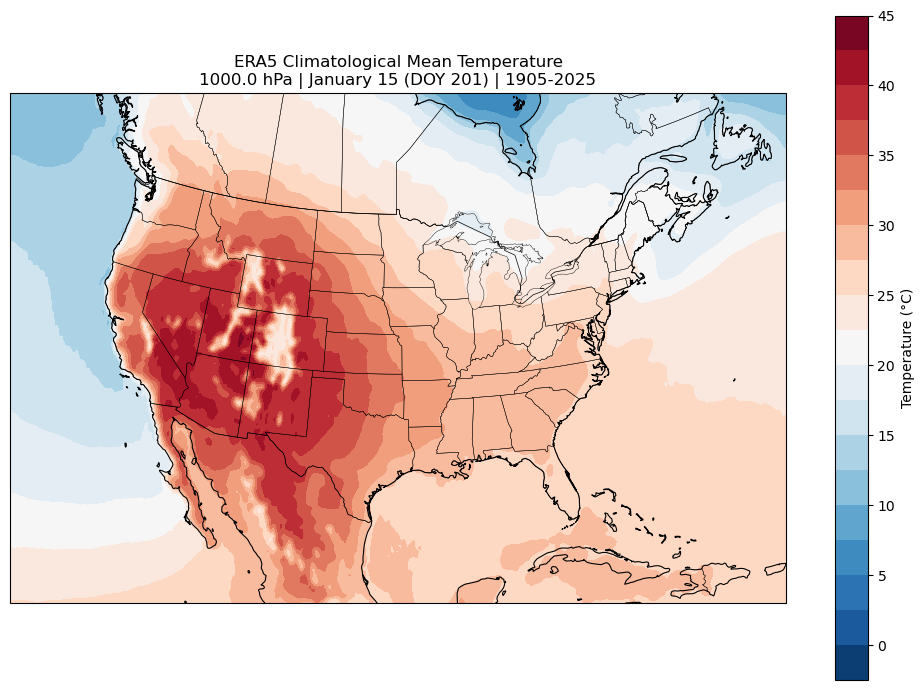

In [4]:
# ── Select January 15 (DOY 15) at 500 hPa ────────────────────────────────────
doy  = 201
lev  = 1000.0
data = climo['T'].sel(doy=doy, level=lev) - 273.15   # convert to Celsius

# ── Plot ──────────────────────────────────────────────────────────────────────
proj = ccrs.LambertConformal(central_longitude=-95, central_latitude=45)

fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={'projection': proj})

# Set map extent to US
ax.set_extent([-125, -65, 20, 55], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5)
ax.add_feature(cfeature.STATES,    linewidth=0.3)

center = 32
spread = 30 

lons = climo['longitude'].values
lats = climo['latitude'].values
im = ax.contourf(lons, lats, data.values,
                 levels=20,
                 cmap='RdBu_r',
                 #vmin = center - spread,
                 #vmax = center + spread,
                 transform=ccrs.PlateCarree())

# Colorbar and labels
plt.colorbar(im, ax=ax, orientation='vertical',
             pad=0.05, label='Temperature (°C)')
ax.set_title(f'ERA5 Climatological Mean Temperature\n'
             f'{lev} hPa | January 15 (DOY {doy}) | 1905-2025',
             fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
clim_all = xr.open_mfdataset('/data1/ERA5/daily_climo/*.nc', combine='by_coords')

/tmp/ipykernel_3445485/2805625467.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  clim_all = xr.open_mfdataset('/data1/ERA5/daily_climo/*.nc', combine='by_coords')


In [13]:
clim_all

<xarray.Dataset> Size: 119GB
Dimensions:    (doy: 365, level: 22, latitude: 321, longitude: 1440)
Coordinates:
  * doy        (doy) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * level      (level) float64 176B 1e+03 925.0 850.0 700.0 ... 7.0 5.0 3.0 1.0
  * latitude   (latitude) float64 3kB 90.0 89.75 89.5 89.25 ... 10.5 10.25 10.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    n_years    (doy) int32 1kB dask.array<chunksize=(365,), meta=np.ndarray>
Data variables:
    O3         (doy, level, latitude, longitude) float32 15GB dask.array<chunksize=(61, 3, 54, 240), meta=np.ndarray>
    PV         (doy, level, latitude, longitude) float32 15GB dask.array<chunksize=(61, 3, 54, 240), meta=np.ndarray>
    T          (doy, level, latitude, longitude) float32 15GB dask.array<chunksize=(61, 3, 54, 240), meta=np.ndarray>
    U          (doy, level, latitude, longitude) float32 15GB dask.array<chunksize=(61, 3, 54, 240), meta=np.ndarray>
    V          (doy, level, latitude, longitude) float32 15GB dask.array<chunksize=(61, 3, 54, 240), meta=np.ndarray>
    W          (doy, level, latitude, longitude) float32 15GB dask.array<chunksize=(61, 3, 54, 240), meta=np.ndarray>
    Z          (doy, level, latitude, longitude) float32 15GB dask.array<chunksize=(61, 3, 54, 240), meta=np.ndarray>
    q          (doy, level, latitude, longitude) float32 15GB dask.array<chunksize=(61, 3, 54, 240), meta=np.ndarray>

In [7]:
ozone = clim_all['O3']
PV = clim_all['PV']
T = clim_all['T']
U = clim_all['U']
V = clim_all['V']
W = clim_all['W']
Z = clim_all['Z']
q = clim_all['q']

In [20]:
Z

<xarray.DataArray 'Z' (doy: 365, level: 22, latitude: 321, longitude: 1440)> Size: 15GB
dask.array<open_dataset-Z, shape=(365, 22, 321, 1440), dtype=float32, chunksize=(61, 3, 54, 240), chunktype=numpy.ndarray>
Coordinates:
  * doy        (doy) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * level      (level) float64 176B 1e+03 925.0 850.0 700.0 ... 7.0 5.0 3.0 1.0
  * latitude   (latitude) float64 3kB 90.0 89.75 89.5 89.25 ... 10.5 10.25 10.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    n_years    (doy) int32 1kB dask.array<chunksize=(365,), meta=np.ndarray>
Attributes:
    long_name:  Daily climatological mean of Z

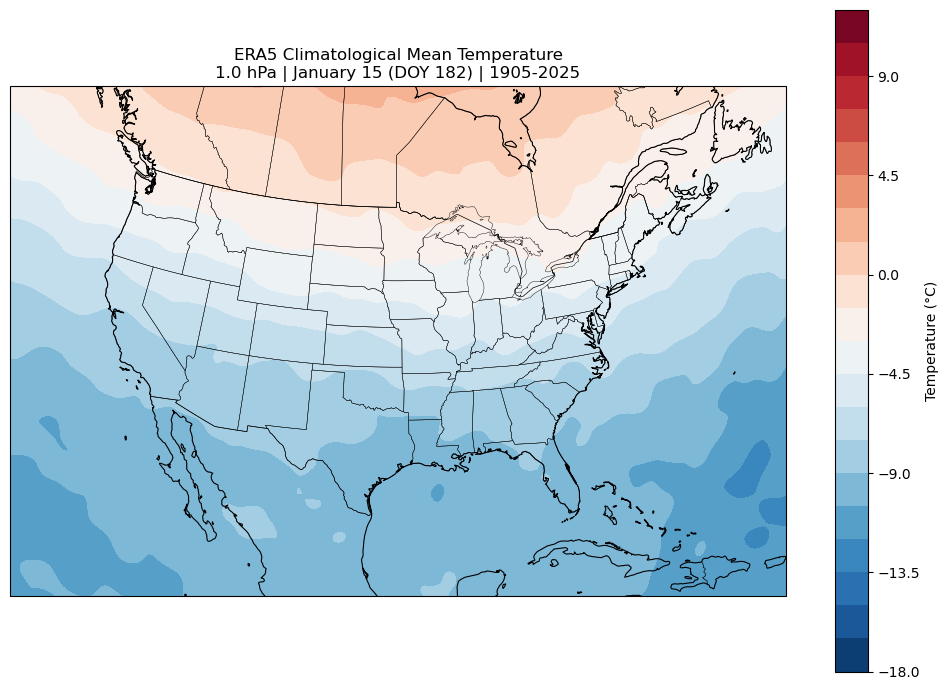

In [19]:
doy  = 182
lev  = 1.0
data = T.sel(doy=doy, level=lev) - 273.15   # convert to Celsius

# ── Plot ──────────────────────────────────────────────────────────────────────
proj = ccrs.LambertConformal(central_longitude=-95, central_latitude=45)

fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={'projection': proj})

# Set map extent to US
ax.set_extent([-125, -65, 20, 55], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5)
ax.add_feature(cfeature.STATES,    linewidth=0.3)

center = 32
spread = 30 

lons = climo['longitude'].values
lats = climo['latitude'].values
im = ax.contourf(lons, lats, data.values,
                 levels=20,
                 cmap='RdBu_r',
                 #vmin = center - spread,
                 #vmax = center + spread,
                 transform=ccrs.PlateCarree())

# Colorbar and labels
plt.colorbar(im, ax=ax, orientation='vertical',
             pad=0.05, label='Temperature (°C)')
ax.set_title(f'ERA5 Climatological Mean Temperature\n'
             f'{lev} hPa | January 15 (DOY {doy}) | 1905-2025',
             fontsize=12)

plt.tight_layout()
plt.show()

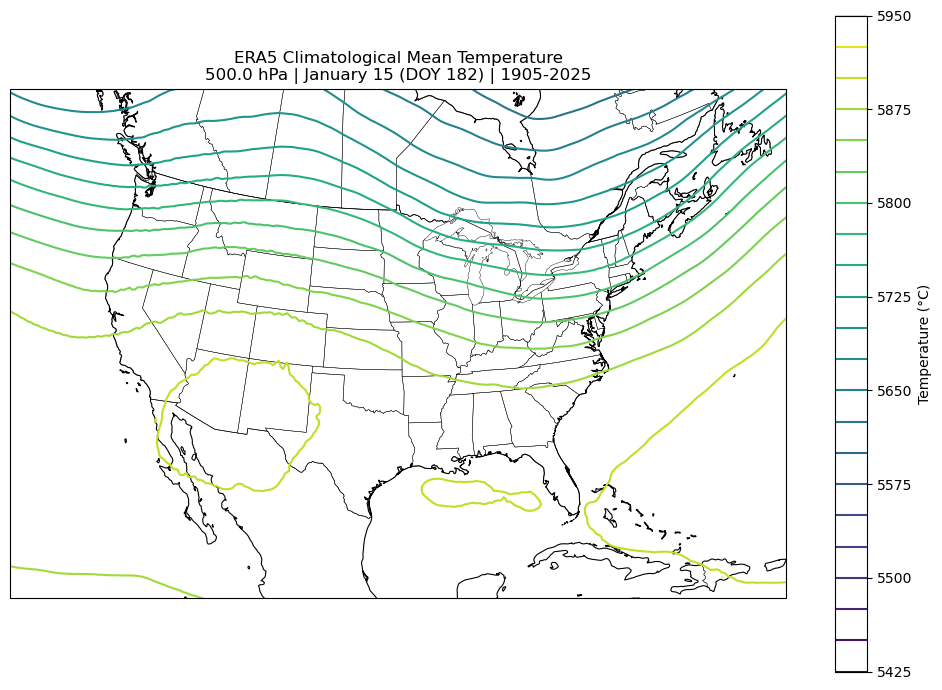

In [27]:
doy  = 182
lev  = 500.0
data = Z.sel(doy=doy, level=lev) / 9.8 ###for geopotential height 

# ── Plot ──────────────────────────────────────────────────────────────────────
proj = ccrs.LambertConformal(central_longitude=-95, central_latitude=45)

fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={'projection': proj})

# Set map extent to US
ax.set_extent([-125, -65, 20, 55], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5)
ax.add_feature(cfeature.STATES,    linewidth=0.3)

center = 32
spread = 30 

lons = climo['longitude'].values
lats = climo['latitude'].values
im = ax.contour(lons, lats, data.values,
                 levels=20,
                 #cmap='RdBu_r',
                 #vmin = center - spread,
                 #vmax = center + spread,
                 transform=ccrs.PlateCarree())

# Colorbar and labels
plt.colorbar(im, ax=ax, orientation='vertical',
             pad=0.05, label='Temperature (°C)')
ax.set_title(f'ERA5 Climatological Mean Temperature\n'
             f'{lev} hPa | January 15 (DOY {doy}) | 1905-2025',
             fontsize=12)

plt.tight_layout()
plt.show()